1- import packages: 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

2- Charge les fichiers CSV du dataset: 

In [5]:
#chemin vers le dossier datasets
data_path = "../datasets/ml-latest-small/"
#charger les fichiers 
movies = pd.read_csv(data_path + "movies.csv")
ratings = pd.read_csv(data_path + "ratings.csv")
tags = pd.read_csv(data_path + "tags.csv")
links = pd.read_csv(data_path + "links.csv")
#afficher premières lignes
print(movies.head())
print(ratings.head())
print(tags.head())
print(links.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2       2    60756     will ferre

3- EDA:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-nul

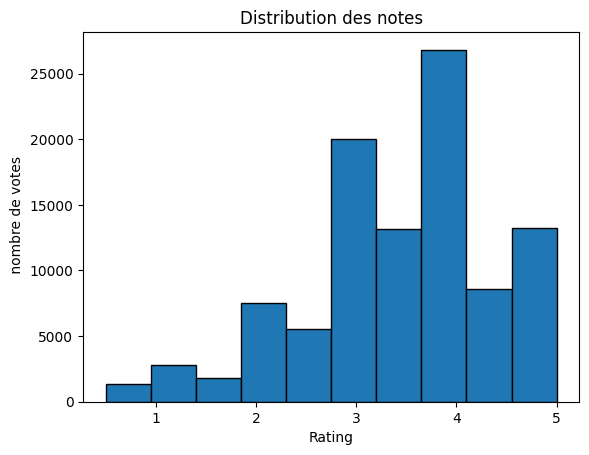

movieId
356     329
318     317
296     307
593     279
2571    278
260     251
480     238
110     237
589     224
527     220
Name: rating, dtype: int64
movieId
187717    5.0
6983      5.0
5328      5.0
95843     5.0
3941      5.0
3940      5.0
3939      5.0
7815      5.0
162414    5.0
162344    5.0
Name: rating, dtype: float64


In [6]:
#general info
movies.info()
ratings.info()
tags.info()
links.info()
#stats de base
movies.describe()
ratings.describe()
tags.describe()
links.describe()
#repartiton des notes
plt.hist(ratings['rating'], bins=10, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel(' nombre de votes')
plt.title('Distribution des notes')
plt.show()
#top 10 films les plus notés
top_10_movies = ratings.groupby('movieId')['rating'].count().sort_values(ascending=False).head(10)
print(top_10_movies)
#top 10 films mieux notés
top_10_rated_movies = ratings.groupby('movieId')['rating'].mean().sort_values(ascending=False).head(10)
print(top_10_rated_movies)

4- préparer les données des films: 

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
#remplacer les genres manquants par ""
movies['genres'] = movies['genres'].fillna('')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
